# GA Optimasi Posisi Object 2D COC Priority, Wall
## Rule
objek: Town hall, defense, storage, army

Aturan:
1. tidak boleh ada yang tumpang tindih
2. tidak overlap
3. prioritas bangunan ditengah
4. Wall connected component
5. Candidate wall tidak boleh berada di dalam footprint building.

Setiap objek mempunyai posisi:
```
A = (x1, y1)
B = (x2, y2)
C = (x3, y3)
D = (x4, y4)
E = (x5, y5)
```

Individual
[
    (x, y, size),
    (x, y, size),
    ...
]

(x,y) menjadi koordinat pojok kiri bawah objek

## Contoh asli bangunan TH13

|	id	|	name	|	count	|	level	|	size	|	category	|	village	|
|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|
|	1000001	|	Town Hall	|	1	|	13	|	[4, 4]	|	Town Hall	|	home	|
|	1000014	|	Clan Castle	|	1	|	9	|	[3, 3]	|	Army	|	home	|
|	1000031	|	Eagle Artillery	|	1	|	4	|	[4, 4]	|	Defense	|	home	|
|	1000067	|	Scattershot	|	2	|	2	|	[3, 3]	|	Defense	|	home	|
|	1000027	|	Inferno Tower	|	3	|	6	|	[2, 2]	|	Defense	|	home	|
|	1000021	|	X-Bow	|	4	|	5	|	[3, 3]	|	Defense	|	home	|
|	1000012	|	Air Defense	|	4	|	9	|	[3, 3]	|	Defense	|	home	|
|	1000028	|	Air Sweeper	|	2	|	7	|	[2, 2]	|	Defense	|	home	|
|	1000009	|	Archer Tower	|	8	|	15	|	[3, 3]	|	Defense	|	home	|
|	1000000	|	Army Camp	|	4	|	11	|	[4, 4]	|	Army	|	home	|
|	1000006	|	Barracks	|	1	|	15	|	[3, 3]	|	Army	|	home	|
|	1000070	|	Blacksmith	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000032	|	Bomb Tower	|	2	|	6	|	[3, 3]	|	Defense	|	home	|
|	1000015	|	Builder's Hut	|	5	|	1	|	[2, 2]	|	Worker	|	home	|
|	1000008	|	Cannon	|	7	|	19	|	[3, 3]	|	Defense	|	home	|
|	1000026	|	Dark Barracks	|	1	|	10	|	[3, 3]	|	Army	|	home	|
|	1000023	|	Dark Elixir Drill	|	3	|	9	|	[3, 3]	|	Resource	|	home	|
|	1000024	|	Dark Elixir Storage	|	1	|	8	|	[3, 3]	|	Resource	|	home	|
|	1000029	|	Dark Spell Factory	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000002	|	Elixir Collector	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000003	|	Elixir Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000004	|	Gold Mine	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000005	|	Gold Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000093	|	Helper Hut	|	1	|	1	|	[3, 3]	|	Helper	|	home	|
|	1000071	|	Hero Hall	|	1	|	7	|	[4, 4]	|	Army	|	home	|
|	1000019	|	Hidden Tesla	|	5	|	9	|	[2, 2]	|	Defense	|	home	|
|	1000007	|	Laboratory	|	1	|	11	|	[3, 3]	|	Army	|	home	|
|	1000013	|	Mortar	|	4	|	12	|	[3, 3]	|	Defense	|	home	|
|	1000020	|	Spell Factory	|	1	|	7	|	[3, 3]	|	Army	|	home	|
|	1000010	|	Wall	|	300	|	14	|	[1, 1]	|	Wall	|	home	|
|	1000011	|	Wizard Tower	|	5	|	10	|	[3, 3]	|	Defense	|	home	|
|	1000059	|	Workshop	|	1	|	5	|	[4, 4]	|	Army	|	home	|


## Import

In [ ]:
import random
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
from PIL import Image

## Data village

In [ ]:
village = {
  "townhall_level": 13,
  "building_count": 393,
  "wall_count": 300,
  "map_size": 44,
  "buildings": [
    {
      "id": 1000001,
      "name": "Town Hall",
      "level": 13,
      "size": [4, 4],
      "category": "Town Hall",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000014,
      "name": "Clan Castle",
      "level": 9,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000031,
      "name": "Eagle Artillery",
      "level": 4,
      "size": [4, 4],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 8
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000006,
      "name": "Barracks",
      "level": 15,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000070,
      "name": "Blacksmith",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000026,
      "name": "Dark Barracks",
      "level": 10,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000024,
      "name": "Dark Elixir Storage",
      "level": 8,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000029,
      "name": "Dark Spell Factory",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000093,
      "name": "Helper Hut",
      "level": 1,
      "size": [3, 3],
      "category": "Helper",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000071,
      "name": "Hero Hall",
      "level": 7,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000007,
      "name": "Laboratory",
      "level": 11,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000020,
      "name": "Spell Factory",
      "level": 7,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000059,
      "name": "Workshop",
      "level": 5,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    }
  ]
}


## Parameter

In [ ]:
# =========================================
# 1. Parameter Genetic Algorithm
# =========================================

POPULATION_SIZE = 50
GENERATIONS = 100
MUTATION_RATE = 0.1

GRID_SIZE = 44

OVERLAP_PENALTY = 1000
BOUNDARY_PENALTY = 1000

BUILDINGS = village["buildings"]
NUMBER_OF_OBJECTS = len(BUILDINGS)

# Priority Center
PRIORITY_BUILDING_IDS = [
    1000001,  # Town Hall
    # 1000014,  # Clan Castle
    # 1000067,  # Scattershot
]
CENTER_RADIUS = 15
CENTER_REWARD_WEIGHT = 150
CLEARANCE_PENALTY = 20
BUILDING_CLEARANCE = 1



In [ ]:
total_area = sum(
    building["size"][0] * building["size"][1]
    for building in BUILDINGS
)

print("Total building area:", total_area)
print("Map area:", GRID_SIZE * GRID_SIZE)

Total building area: 818
Map area: 1936


## Function

In [ ]:
# =========================================
# Center Radius
# =========================================
def random_center_position(size):

    width, height = size

    center_x = GRID_SIZE // 2
    center_y = GRID_SIZE // 2

    min_x = max(
        0,
        center_x - CENTER_RADIUS
    )

    max_x = min(
        GRID_SIZE - width,
        center_x + CENTER_RADIUS
    )

    min_y = max(
        0,
        center_y - CENTER_RADIUS
    )

    max_y = min(
        GRID_SIZE - height,
        center_y + CENTER_RADIUS
    )

    x = random.randint(min_x, max_x)
    y = random.randint(min_y, max_y)

    return (x, y)

# =========================================
# memperbaiki crossover
# =========================================
def repair(individual):

    repaired = [None] * NUMBER_OF_OBJECTS

    for i in range(NUMBER_OF_OBJECTS):

        position = individual[i]
        size = BUILDINGS[i]["size"]

        placed = [
            (
                repaired[j],
                BUILDINGS[j]["size"]
            )
            for j in range(i)
            if repaired[j] is not None
        ]

        if position is not None:

            if position_is_valid(
                position,
                size,
                placed
            ):
                repaired[i] = position
                continue

        # Jika posisi invalid, cari posisi baru
        new_position = find_valid_position(
            size,
            placed,
            center=(
                BUILDINGS[i]["id"]
                in PRIORITY_BUILDING_IDS
            )
        )

        if new_position is None:
            # fallback
            width, height = size

            new_position = (
                random.randint(
                    0,
                    GRID_SIZE - width
                ),
                random.randint(
                    0,
                    GRID_SIZE - height
                )
            )

        repaired[i] = new_position

    return repaired

# =========================================
# Pengecekan posisi agar tidak overlap ditengah
# =========================================
def position_is_valid(
    position,
    size,
    placed_buildings
):

    for other_position, other_size in placed_buildings:

        if is_overlap(
            position,
            size,
            other_position,
            other_size
        ):
            return False

    return True

def find_valid_position(
    size,
    placed_buildings,
    center=False,
    max_attempts=100
):

    for _ in range(max_attempts):

        if center:
            position = random_center_position(size)

        else:

            width, height = size

            x = random.randint(
                0,
                GRID_SIZE - width
            )

            y = random.randint(
                0,
                GRID_SIZE - height
            )

            position = (x, y)

        if position_is_valid(
            position,
            size,
            placed_buildings
        ):
            return position

    return None

In [ ]:
# =========================================
# Fungsi Distance
# =========================================

def distance(point1, point2):

    x1, y1 = point1
    x2, y2 = point2

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )
    
def building_center(position, size):

    x, y = position
    width, height = size

    return (
        x + width / 2,
        y + height / 2
    )
   
def center_distance(position, size):

    x, y = building_center(
        position,
        size
    )

    center_x = GRID_SIZE / 2
    center_y = GRID_SIZE / 2

    return math.sqrt(
        (x - center_x) ** 2 +
        (y - center_y) ** 2
    )
    
# =========================================
# Fungsi Overlap bangunan 2D
# =========================================
def is_overlap(pos1, size1, pos2, size2):

    x1, y1 = pos1
    w1, h1 = size1

    x2, y2 = pos2
    w2, h2 = size2

    return (
        x1 < x2 + w2 and
        x1 + w1 > x2 and
        y1 < y2 + h2 and
        y1 + h1 > y2
    )

# =========================================
# Agar bangunan tidak berdempetan
# =========================================
def is_too_close(
    pos1,
    size1,
    pos2,
    size2,
    clearance=1
):

    x1, y1 = pos1
    w1, h1 = size1

    x2, y2 = pos2
    w2, h2 = size2

    # Horizontal separation
    if x1 + w1 < x2:
        dx = x2 - (x1 + w1)

    elif x2 + w2 < x1:
        dx = x1 - (x2 + w2)

    else:
        dx = 0


    # Vertical separation
    if y1 + h1 < y2:
        dy = y2 - (y1 + h1)

    elif y2 + h2 < y1:
        dy = y1 - (y2 + h2)

    else:
        dy = 0


    if is_overlap(
        pos1,
        size1,
        pos2,
        size2
    ):
        return False


    min_distance = math.sqrt(
        dx ** 2 +
        dy ** 2
    )

    return min_distance < clearance


# =========================================
# 2. Fungsi Fitness
# =========================================

def fitness(individual):

    penalty = 0
    center_reward = 0
    clearance_penalty = 0

    # =====================================
    # Boundary
    # =====================================

    for i, building in enumerate(BUILDINGS):

        x, y = individual[i]

        width, height = building["size"]

        if x < 0:
            penalty += BOUNDARY_PENALTY

        if y < 0:
            penalty += BOUNDARY_PENALTY

        if x + width > GRID_SIZE:
            penalty += BOUNDARY_PENALTY

        if y + height > GRID_SIZE:
            penalty += BOUNDARY_PENALTY


    # =====================================
    # Building relationship
    # =====================================

    for i in range(NUMBER_OF_OBJECTS):

        for j in range(i + 1, NUMBER_OF_OBJECTS):

            pos1 = individual[i]
            pos2 = individual[j]

            size1 = BUILDINGS[i]["size"]
            size2 = BUILDINGS[j]["size"]

            # Overlap
            if is_overlap(
                pos1,
                size1,
                pos2,
                size2
            ):
                penalty += OVERLAP_PENALTY

            # Clearance
            elif is_too_close(
                pos1,
                size1,
                pos2,
                size2,
                clearance=1
            ):
                clearance_penalty += CLEARANCE_PENALTY


    # =====================================
    # Center Priority
    # =====================================

    for i, building in enumerate(BUILDINGS):

        if building["id"] in PRIORITY_BUILDING_IDS:

            d = center_distance(
                individual[i],
                building["size"]
            )

            center_reward += (
                CENTER_REWARD_WEIGHT /
                (1 + d)
            )


    return (
        center_reward
        - penalty
        - clearance_penalty
    )


# =========================================
# 3. Membuat individual
# =========================================

def create_individual():

    individual = [None] * NUMBER_OF_OBJECTS

    placed_buildings = []

    # =====================================
    # 1. PRIORITY BUILDINGS
    # =====================================

    priority_indices = []

    for i, building in enumerate(BUILDINGS):

        if building["id"] in PRIORITY_BUILDING_IDS:

            priority_indices.append(i)


    # =====================================
    # 2. PLACE PRIORITY
    # =====================================

    for i in priority_indices:

        building = BUILDINGS[i]
        size = building["size"]

        position = find_valid_position(
            size,
            placed_buildings,
            center=True
        )

        if position is None:
            raise RuntimeError(
                f"Gagal menempatkan "
                f"{building['name']} "
                f"instance {building['instance']}"
            )

        individual[i] = position

        placed_buildings.append(
            (position, size)
        )


    # =====================================
    # 3. PLACE OTHER BUILDINGS
    # =====================================

    for i, building in enumerate(BUILDINGS):

        if individual[i] is not None:
            continue

        size = building["size"]

        position = find_valid_position(
            size,
            placed_buildings,
            center=False
        )

        if position is None:
            raise RuntimeError(
                f"Gagal menempatkan "
                f"{building['name']} "
                f"instance {building['instance']}"
            )

        individual[i] = position

        placed_buildings.append(
            (position, size)
        )


    return individual

In [ ]:
# =========================================
# 5. Membuat population
# =========================================

def create_population():
    return [
        create_individual()
        for _ in range(POPULATION_SIZE)
    ]


# =========================================
# 6. Selection
# =========================================

def selection(population):
    population_sorted = sorted(
        population,
        key=fitness,
        reverse=True
    )

    # Ambil 50% terbaik
    return population_sorted[:POPULATION_SIZE // 2]


# =========================================
# 7. Crossover
# =========================================
def crossover(parent1, parent2):

    point = random.randint(
        1,
        NUMBER_OF_OBJECTS - 1
    )

    child1 = (
        parent1[:point]
        + parent2[point:]
    )

    child2 = (
        parent2[:point]
        + parent1[point:]
    )

    return child1, child2

# =========================================
# 8. Mutation
# =========================================
def mutation(individual):

    mutated = individual.copy()

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < MUTATION_RATE:

            x, y = mutated[i]

            dx = random.choice([-2, -1, 1, 2])
            dy = random.choice([-2, -1, 1, 2])

            width, height = BUILDINGS[i]["size"]

            new_x = max(
                0,
                min(
                    x + dx,
                    GRID_SIZE - width
                )
            )

            new_y = max(
                0,
                min(
                    y + dy,
                    GRID_SIZE - height
                )
            )

            mutated[i] = (
                new_x,
                new_y
            )

    return mutated




## Run GA

In [ ]:
# =========================================
# 9. Genetic Algorithm
# =========================================

population = create_population()


for generation in range(GENERATIONS):

    # -----------------------------
    # Evaluasi
    # -----------------------------

    best = max(
        population,
        key=fitness
    )

    print(
        f"Generation {generation + 1:02d} | "
        f"Fitness = {fitness(best):.2f} | "
        f"Position = {best}"
    )


    # -----------------------------
    # Selection
    # -----------------------------

    parents = selection(population)


    # -----------------------------
    # Membuat population baru
    # -----------------------------

    new_population = parents.copy()


    while len(new_population) < POPULATION_SIZE:

        parent1, parent2 = random.sample(parents, 2)

        child1, child2 = crossover(
            parent1,
            parent2
        )

        child1 = mutation(child1)
        child2 = mutation(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)


    population = new_population


# =========================================
# 10. Hasil akhir
# =========================================

best = max(
    population,
    key=fitness
)

print("\nHasil Akhir")

fitness_values = [
    fitness(individual)
    for individual in population
]

best_fitness = max(fitness_values)
average_fitness = sum(fitness_values) / len(fitness_values)
worst_fitness = min(fitness_values)

print(
    f"Generation {generation + 1:03d} | "
    f"Best = {best_fitness:.2f} | "
    f"Average = {average_fitness:.2f} | "
    f"Worst = {worst_fitness:.2f}"
)

print("="*50)
print("Position :", best)
print("Fitness  :", fitness(best))



Generation 01 | Fitness = -1073.65 | Position = [(18, 19), (34, 4), (13, 35), (9, 29), (26, 34), (24, 9), (6, 7), (37, 18), (22, 28), (21, 40), (41, 25), (36, 13), (8, 26), (37, 1), (33, 14), (14, 31), (21, 13), (9, 2), (18, 23), (4, 41), (35, 33), (35, 20), (5, 21), (7, 39), (34, 41), (41, 4), (29, 27), (14, 14), (23, 12), (21, 32), (19, 15), (18, 1), (18, 7), (35, 24), (29, 1), (1, 37), (25, 29), (29, 42), (16, 11), (9, 35), (17, 35), (4, 35), (36, 28), (27, 22), (35, 38), (21, 8), (30, 19), (0, 16), (29, 11), (10, 6), (1, 13), (29, 36), (1, 1), (41, 29), (12, 27), (10, 40), (0, 39), (41, 37), (0, 8), (6, 3), (11, 24), (8, 14), (26, 5), (21, 36), (6, 32), (12, 3), (26, 1), (15, 25), (34, 9), (29, 8), (2, 30), (27, 17), (11, 17), (1, 4), (22, 4), (11, 20), (33, 24), (3, 38), (19, 28), (11, 11), (5, 12), (40, 10), (6, 18), (38, 32), (1, 33), (30, 15), (8, 11), (14, 7), (12, 0), (1, 21), (2, 27), (18, 39), (22, 24)]
Generation 02 | Fitness = -1073.65 | Position = [(18, 19), (34, 4), (13

## Visualisasi

TypeError: 'float' object is not callable

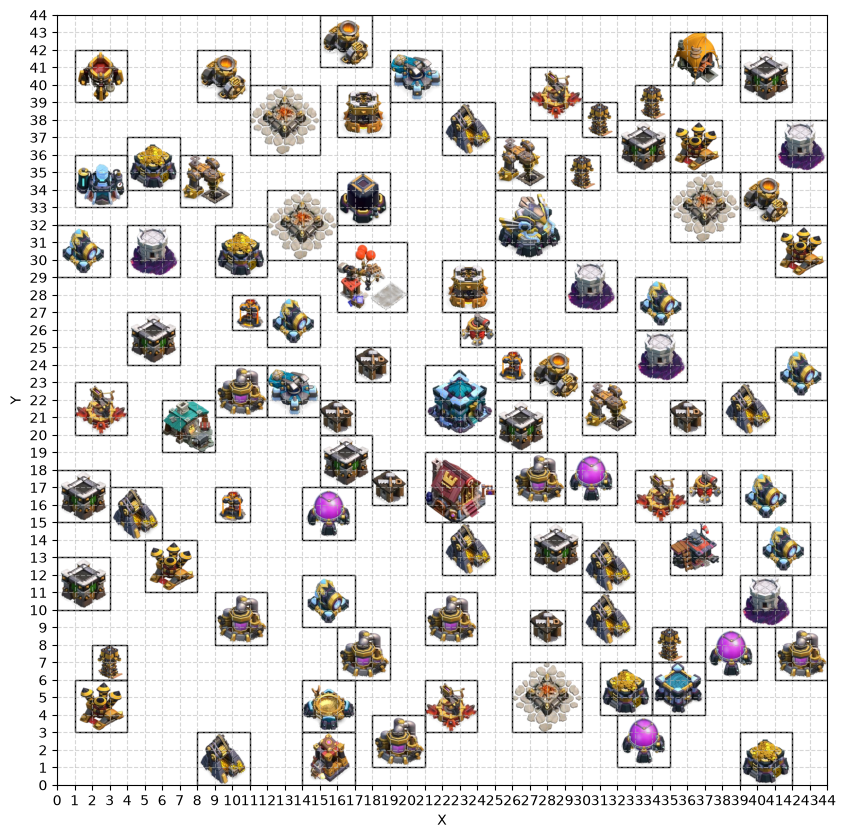

In [59]:
best = [(21, 20), (34, 4), (25, 30), (12, 21), (19, 39), (25, 23), (10, 26), (9, 15), (27, 38), (33, 15), (1, 20), (21, 3), (5, 11), (41, 29), (35, 35), (1, 3), (23, 25), (36, 16), (27, 12), (0, 15), (15, 17), (0, 10), (25, 19), (39, 39), (4, 24), (32, 35), (12, 30), (11, 36), (26, 3), (35, 31), (35, 12), (6, 19), (22, 27), (16, 37), (35, 20), (27, 8), (15, 20), (17, 23), (18, 16), (12, 25), (33, 26), (0, 29), (40, 12), (41, 22), (14, 9), (39, 15), (14, 0), (25, 34), (30, 20), (7, 33), (16, 32), (1, 39), (18, 1), (9, 8), (26, 16), (41, 6), (9, 21), (21, 8), (16, 6), (14, 14), (29, 16), (32, 1), (37, 6), (3, 14), (22, 12), (38, 20), (8, 0), (30, 11), (30, 8), (22, 36), (31, 4), (39, 0), (4, 34), (9, 29), (35, 40), (21, 15), (2, 6), (29, 34), (30, 37), (34, 7), (33, 38), (1, 33), (8, 39), (15, 41), (27, 22), (39, 32), (14, 3), (41, 35), (4, 29), (39, 9), (29, 27), (33, 23), (16, 27)]

# =========================================
# 11. Visualisasi
# =========================================

fig, ax = plt.subplots(figsize=(10, 10))

for i, (x, y) in enumerate(best):
  bld = BUILDINGS[i]
  width, height = bld["size"]
  name = bld["name"]
  bld_id = bld["id"]
  level = bld["level"]

  rectangle = Rectangle(
      (x, y), width, height, fill=False, linewidth=1, edgecolor="black"
  )
  ax.add_patch(rectangle)

  folder_name_suffix = name.lower().replace(" ", "_")
  folder_path = f"../../../assets/buildings/{bld_id}_{folder_name_suffix}"

  file_prefix = name.replace(" ", "_")
  img_filename = f"{file_prefix}{level}.webp"
  img_path = os.path.join(folder_path, img_filename)

  try:
    if os.path.exists(img_path):
      img = Image.open(img_path)
      ax.imshow(img, extent=(x, x + width, y, y + height), aspect="auto")
    else:
      print(f"Gambar tidak ditemukan: {img_path}")
  except Exception as e:
    print(f"Gagal memuat gambar {name}: {e}")

#   ax.text(
#       x + width / 2,
#       y + height / 2,
#       f"{name}\n(Lvl {level})",
#       ha="center",
#       va="center",
#       fontsize=5,
#       color="white",
#       weight="bold",
#       bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1),
#   )

# =========================================
# Map
# =========================================

# Pastikan GRID_SIZE sudah terdefinisi di kode Anda (misal: 44)
GRID_SIZE = village.get("map_size", 44)

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)

ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_aspect("equal")

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title(f"COC Base Optimization\nFitness = {fitness(best):.2f}")

plt.show()

## Result Building

# GA WALL

## Import Wall

In [60]:
# Wall
BUILDING_CELL = 1
WALL_CANDIDATE_CELL = 2
WALL_DISTANCE = 1

# Wall Connector
GAP_WALL_SCORE = 100
NORMAL_WALL_SCORE = 10

MAX_WALLS = 300

## Function

In [61]:
def create_occupancy_grid():

    grid = [
        [0 for _ in range(GRID_SIZE)]
        for _ in range(GRID_SIZE)
    ]

    return grid

# =========================================
# 3. Mengisi Building ke Occupancy Grid
# =========================================

def place_buildings_on_grid(
    grid,
    buildings,
    positions
):

    for i, building in enumerate(buildings):

        x, y = positions[i]

        width, height = building["size"]

        for dy in range(height):

            for dx in range(width):

                grid[y + dy][x + dx] = BUILDING_CELL

    return grid

# =========================================
# Cek koordinat dalam map
# =========================================

def is_inside_grid(x, y):

    return (
        0 <= x < GRID_SIZE and
        0 <= y < GRID_SIZE
    )

# =========================================
# Tetangga Building
# =========================================

def get_building_neighbors(grid, x, y):

    neighbors = []

    directions = [
        (0, 1),   # atas
        (0, -1),  # bawah
        (-1, 0),  # kiri
        (1, 0)    # kanan
    ]

    for dx, dy in directions:

        nx = x + dx
        ny = y + dy

        if is_inside_grid(nx, ny):

            if grid[ny][nx] == BUILDING_CELL:
                neighbors.append((nx, ny))

    return neighbors    

# =========================================
# Deteksi Gap Wall
# =========================================

def is_between_buildings(grid, x, y):

    # Horizontal
    left = (x - 1, y)
    right = (x + 1, y)

    if (
        is_inside_grid(*left)
        and is_inside_grid(*right)
        and grid[left[1]][left[0]] == BUILDING_CELL
        and grid[right[1]][right[0]] == BUILDING_CELL
    ):
        return True

    # Vertical
    top = (x, y + 1)
    bottom = (x, y - 1)

    if (
        is_inside_grid(*top)
        and is_inside_grid(*bottom)
        and grid[top[1]][top[0]] == BUILDING_CELL
        and grid[bottom[1]][bottom[0]] == BUILDING_CELL
    ):
        return True

    return False

# =========================================
# Score Candidate Wall
# =========================================

def score_wall_candidate(grid, x, y):

    score = 0

    neighbors = get_building_neighbors(
        grid,
        x,
        y
    )

    # -------------------------------------
    # 1. Gap antara dua building
    # -------------------------------------

    if is_between_buildings(grid, x, y):

        score += GAP_WALL_SCORE

    # -------------------------------------
    # 2. Banyak building di sekitar
    # -------------------------------------

    score += len(neighbors) * 10

    # -------------------------------------
    # 3. Candidate biasa
    # -------------------------------------

    if len(neighbors) > 0:

        score += NORMAL_WALL_SCORE

    return score 

# =========================================
# Cek koneksi Wall
# =========================================

def get_wall_neighbors(position):

    x, y = position

    return [
        (x + 1, y),
        (x - 1, y),
        (x, y + 1),
        (x, y - 1)
    ]

# =========================================
# Wall Connector
# =========================================
def connect_walls(
    grid,
    candidate_walls,
    max_walls=MAX_WALLS
):

    selected_walls = set()

    remaining = set(candidate_walls)

    # -------------------------------------
    # Cari candidate dengan score tertinggi
    # -------------------------------------

    scored_candidates = []

    for x, y in candidate_walls:

        score = score_wall_candidate(
            grid,
            x,
            y
        )

        scored_candidates.append(
            ((x, y), score)
        )

    scored_candidates.sort(
        key=lambda item: item[1],
        reverse=True
    )

    # -------------------------------------
    # Seed pertama
    # -------------------------------------

    if not scored_candidates:
        return selected_walls

    seed = scored_candidates[0][0]

    selected_walls.add(seed)
    remaining.remove(seed)

    # -------------------------------------
    # Grow wall
    # -------------------------------------

    while len(selected_walls) < max_walls:

        connected_candidates = []

        for candidate in remaining:

            neighbors = get_wall_neighbors(
                candidate
            )

            # Candidate harus bersebelahan
            # dengan wall yang sudah dipilih
            if any(
                neighbor in selected_walls
                for neighbor in neighbors
            ):

                x, y = candidate

                score = score_wall_candidate(
                    grid,
                    x,
                    y
                )

                connected_candidates.append(
                    (candidate, score)
                )

        # Tidak ada candidate yang
        # bisa melanjutkan koneksi
        if not connected_candidates:
            break

        # Pilih candidate terbaik
        connected_candidates.sort(
            key=lambda item: item[1],
            reverse=True
        )

        selected = connected_candidates[0][0]

        selected_walls.add(selected)
        remaining.remove(selected)

    return selected_walls

# =========================================
# 5. Generate Candidate Wall
# =========================================

def generate_candidate_walls(grid):

    candidates = set()

    for y in range(GRID_SIZE):

        for x in range(GRID_SIZE):

            # Bukan building
            if grid[y][x] != BUILDING_CELL:
                continue

            # Cek 8 arah
            for dy in range(-WALL_DISTANCE, WALL_DISTANCE + 1):

                for dx in range(-WALL_DISTANCE, WALL_DISTANCE + 1):

                    # Jangan cek cell building itu sendiri
                    if dx == 0 and dy == 0:
                        continue

                    nx = x + dx
                    ny = y + dy

                    # Harus berada dalam grid
                    if not is_inside_grid(nx, ny):
                        continue

                    # Tidak boleh berada di atas building
                    if grid[ny][nx] == BUILDING_CELL:
                        continue

                    candidates.add((nx, ny))

    return candidates

# =========================================
# 6. Generate Occupancy
# =========================================

occupancy_grid = create_occupancy_grid()

occupancy_grid = place_buildings_on_grid(
    occupancy_grid,
    BUILDINGS,
    best
)



    

## Run Wall

Building count : 93
Candidate walls : 808
Candidate data : {(38, 23), (7, 26), (18, 26), (15, 39), (26, 39), (18, 35), (19, 0), (42, 2), (29, 32), (8, 9), (19, 9), (42, 11), (0, 5), (29, 41), (19, 18), (8, 18), (21, 37), (0, 14), (11, 14), (0, 23), (33, 20), (33, 29), (41, 42), (25, 25), (4, 2), (10, 36), (2, 32), (34, 12), (22, 19), (34, 21), (34, 30), (14, 24), (3, 24), (38, 0), (3, 42), (15, 7), (26, 7), (38, 9), (7, 3), (14, 42), (38, 18), (26, 25), (15, 25), (7, 30), (19, 4), (30, 4), (11, 0), (29, 36), (40, 36), (0, 9), (41, 19), (41, 28), (25, 11), (25, 29), (2, 36), (37, 3), (25, 38), (3, 10), (14, 19), (3, 19), (37, 21), (14, 28), (3, 28), (37, 30), (3, 37), (26, 2), (26, 11), (36, 43), (29, 31), (40, 31), (21, 27), (41, 5), (21, 36), (33, 10), (25, 6), (10, 17), (33, 19), (2, 13), (25, 15), (10, 35), (34, 11), (3, 23), (36, 29), (15, 6), (17, 25), (28, 25), (7, 2), (36, 38), (28, 34), (40, 8), (29, 8), (6, 15), (21, 13), (29, 26), (6, 33), (40, 35), (10, 3), (41, 18), (33, 14

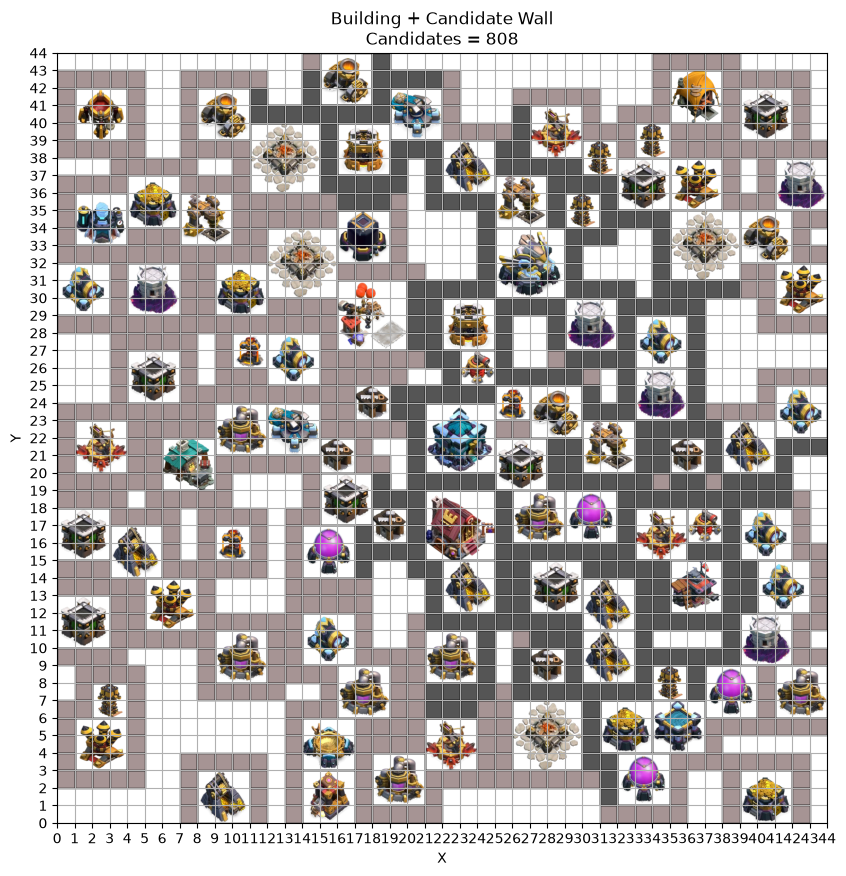

In [62]:
# =========================================
# Generate Candidate Wall
# =========================================

candidate_walls = generate_candidate_walls(
    occupancy_grid
)

print("Building count :", len(BUILDINGS))
print("Candidate walls :", len(candidate_walls))
print("Candidate data :", candidate_walls)

# =========================================
# Generate Connected Wall
# =========================================

wall_positions = connect_walls(
    occupancy_grid,
    candidate_walls,
    max_walls=300
)

print("Building count :", len(BUILDINGS))
print("Candidate walls :", len(candidate_walls))
print("Selected walls  :", len(wall_positions))


# =========================================
# 7. Visualisasi Candidate Wall
# =========================================

fig, ax = plt.subplots(figsize=(10, 10))


# =========================================
# Building
# =========================================

for i, (x, y) in enumerate(best):
  bld = BUILDINGS[i]
  width, height = bld["size"]
  name = bld["name"]
  bld_id = bld["id"]
  level = bld["level"]

  rectangle = Rectangle(
      (x, y), width, height, fill=False, linewidth=1, edgecolor="black"
  )
  ax.add_patch(rectangle)

  folder_name_suffix = name.lower().replace(" ", "_")
  folder_path = f"../../../assets/buildings/{bld_id}_{folder_name_suffix}"

  file_prefix = name.replace(" ", "_")
  img_filename = f"{file_prefix}{level}.webp"
  img_path = os.path.join(folder_path, img_filename)

  try:
    if os.path.exists(img_path):
      img = Image.open(img_path)
      ax.imshow(img, extent=(x, x + width, y, y + height), aspect="auto")
    else:
      print(f"Gambar tidak ditemukan: {img_path}")
  except Exception as e:
    print(f"Gagal memuat gambar {name}: {e}")

#   ax.text(
#       x + width / 2,
#       y + height / 2,
#       f"{name}\n(Lvl {level})",
#       ha="center",
#       va="center",
#       fontsize=5,
#       color="white",
#       weight="bold",
#       bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1),
#   )



# =========================================
# Candidate Wall
# =========================================

for x, y in candidate_walls:

    rectangle = Rectangle(
        (x, y),
        1,
        1,
        fill=True,
        facecolor='#a69494',
        edgecolor='black',
        linewidth=1
    )

    ax.add_patch(rectangle)

# =========================================
# Selected Wall
# =========================================

for x, y in wall_positions:

    rectangle = Rectangle(
        (x, y),
        1,
        1,
        fill=True,
        facecolor="#555555",
        edgecolor="black",
        linewidth=1
    )

    ax.add_patch(rectangle)


# =========================================
# Grid
# =========================================

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)

ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))

ax.grid(True)

ax.set_aspect("equal")

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title(
    f"Building + Candidate Wall\n"
    f"Candidates = {len(candidate_walls)}"
)

plt.show()

## Result